# <center>Case Study 6: TPGR Uncertainty and Energy Landscapes</center>

Run TPGR in RAVEN on the same 2D parameterized field family used earlier, compare the selected sensors against pySensors, and visualize the full candidate-sensor uncertainty, one-point energy, and two-point energy landscapes.

In [1]:

import os
import sys
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import patches
from IPython.display import HTML, display
import numpy as np
import pandas as pd
import pysensors as ps


def find_repo_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "ravenframework").is_dir() and (path / "tests").is_dir():
            return path
    raise RuntimeError("Could not locate the repository root from the current working directory.")


repo_root = find_repo_root()
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.22})
seed = 42
NX = 18
NY = 12
x_axis = np.linspace(0.0, 1.0, NX)
y_axis = np.linspace(0.0, 1.0, NY)
XX, YY = np.meshgrid(x_axis, y_axis, indexing="xy")
X = XX.ravel()
Y = YY.ravel()
point_id = np.arange(X.size)
alphas = np.linspace(0.1, 1.0, 6)
time_slice = 0.45


def parameter_field(alpha, t=time_slice):
    left = np.exp(-(((X - (0.25 + 0.10 * alpha)) / 0.16) ** 2 + ((Y - 0.35) / 0.18) ** 2))
    right = np.exp(-(((X - 0.72) / 0.18) ** 2 + ((Y - (0.68 - 0.08 * alpha)) / 0.16) ** 2))
    wave = np.sin((2.0 + alpha) * np.pi * X) * np.cos(2.0 * np.pi * Y)
    return np.exp(-0.85 * t) * ((2.0 + 0.25 * alpha) * left + (0.6 + 1.35 * alpha) * right) + 0.28 * np.cos(2.0 * np.pi * t) * wave


def sensor_costs():
    expensive_center = 1.0 + 4.0 * np.exp(-(((X - 0.52) / 0.22) ** 2 + ((Y - 0.50) / 0.20) ** 2))
    edge_bonus = 0.5 * (np.abs(X - 0.5) + np.abs(Y - 0.5))
    return expensive_center + edge_bonus


def field_image(values):
    return np.asarray(values, dtype=float).reshape(NY, NX)


def spatial_frame(ax, values, title, limits=None, cmap="coolwarm", sensors=None):
    if limits is None:
        limits = (float(np.nanmin(values)), float(np.nanmax(values)))
    image = ax.imshow(
        field_image(values),
        extent=[x_axis.min(), x_axis.max(), y_axis.min(), y_axis.max()],
        origin="lower",
        cmap=cmap,
        vmin=limits[0],
        vmax=limits[1],
        interpolation="bicubic",
        aspect="equal",
    )
    if sensors is not None:
        sensors = np.asarray(sensors, dtype=int)
        ax.scatter(X[sensors], Y[sensors], facecolors="none", edgecolors="black", s=82, linewidths=1.2)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="box")
    return image


def nearest_point_indices(frame, x_col="x", y_col="y"):
    grid = np.column_stack([X, Y])
    indices = []
    distances = []
    for _, row in frame.iterrows():
        point = np.array([row[x_col], row[y_col]])
        distance = np.linalg.norm(grid - point, axis=1)
        index = int(np.argmin(distance))
        indices.append(index)
        distances.append(float(distance[index]))
    return np.asarray(indices, dtype=int), np.asarray(distances)


def style_sensor_comparison(table, caption, columns=None):
    if columns is None:
        columns = [
            "case", "match", "order_match", "sensor_id", "pySensors order", "RAVEN order",
            "pySensors value", "RAVEN value", "pySensors coefficient",
            "pySensors x", "RAVEN x", "pySensors y", "RAVEN y", "nearest_grid_distance",
        ]
    visible_columns = [column for column in columns if column in table.columns]

    def highlight(row):
        sensor_match = bool(row.get("match", False))
        order_match = bool(row.get("order_match", True))
        if sensor_match and order_match:
            return ["background-color: #d9ead3; color: #073b18" for _ in row]
        if sensor_match:
            return ["background-color: #fff2cc; color: #4a3600" for _ in row]
        return ["background-color: #f4cccc; color: #5f1010" for _ in row]

    fmt = {
        "match": lambda value: "yes" if bool(value) else "no",
        "order_match": lambda value: "yes" if bool(value) else "no",
        "pySensors order": "{:.0f}",
        "RAVEN order": "{:.0f}",
        "pySensors value": "{:.6f}",
        "RAVEN value": "{:.6f}",
        "pySensors coefficient": "{:.6f}",
        "pySensors x": "{:.6f}",
        "RAVEN x": "{:.6f}",
        "pySensors y": "{:.6f}",
        "RAVEN y": "{:.6f}",
        "nearest_grid_distance": "{:.2e}",
    }
    return (
        table[visible_columns]
        .style
        .apply(highlight, axis=1)
        .format({key: value for key, value in fmt.items() if key in visible_columns}, na_rep="-")
        .hide(axis="index")
        .set_caption(caption)
    )


def style_match_table(table, caption):
    def highlight(row):
        if bool(row.get("match", False)):
            return ["background-color: #d9ead3; color: #073b18" for _ in row]
        return ["background-color: #f4cccc; color: #5f1010" for _ in row]

    fmt = {
        "match": lambda value: "yes" if bool(value) else "no",
        "pySensors rmse": "{:.6e}",
        "RAVEN rec_rmse": "{:.6e}",
        "relative_l2": "{:.6e}",
        "rmse": "{:.6e}",
    }
    return (
        table
        .style
        .apply(highlight, axis=1)
        .format({key: value for key, value in fmt.items() if key in table.columns}, na_rep="-")
        .hide(axis="index")
        .set_caption(caption)
    )

def compare_sensor_tables(case_name, pysensors_indices, raven_frame, reference_matrix):
    raven_indices, raven_distances = nearest_point_indices(raven_frame)
    pysensors_compare = pd.DataFrame({
        "case": case_name,
        "sensor_id": np.asarray(pysensors_indices, dtype=int),
        "pySensors order": np.arange(1, len(pysensors_indices) + 1),
        "pySensors value": reference_matrix[0, pysensors_indices],
        "pySensors x": X[pysensors_indices],
        "pySensors y": Y[pysensors_indices],
    })
    raven_compare = pd.DataFrame({
        "case": case_name,
        "sensor_id": raven_indices,
        "RAVEN order": raven_frame["sensor"].to_numpy(),
        "RAVEN value": raven_frame["T"].to_numpy(),
        "RAVEN x": raven_frame["x"].to_numpy(),
        "RAVEN y": raven_frame["y"].to_numpy(),
        "nearest_grid_distance": raven_distances,
    })
    comparison = pysensors_compare.merge(raven_compare, on=["case", "sensor_id"], how="outer")
    comparison = comparison.sort_values(["case", "pySensors order", "RAVEN order"], na_position="last").reset_index(drop=True)
    comparison["same sensor"] = comparison["pySensors order"].notna() & comparison["RAVEN order"].notna()
    comparison["same location"] = np.isclose(comparison["pySensors x"], comparison["RAVEN x"]) & np.isclose(comparison["pySensors y"], comparison["RAVEN y"])
    comparison["same value"] = np.isclose(comparison["pySensors value"], comparison["RAVEN value"])
    comparison["match"] = comparison[["same sensor", "same location", "same value"]].all(axis=1)
    comparison["order_match"] = comparison["pySensors order"].eq(comparison["RAVEN order"])
    return comparison, raven_indices


def run_raven(raven_case_dir, raven_input):
    raven_case_dir.mkdir(parents=True, exist_ok=True)
    raven_output = raven_case_dir / "outPP.csv"
    if raven_output.exists():
        raven_output.unlink()

    import subprocess
    run_env = os.environ.copy()
    run_env["PATH"] = f"{repo_root}{os.pathsep}{run_env.get('PATH', '')}"
    run_env["INSTALLATION_MANAGER"] = "CONDA"
    run_env["RAVEN_LIBS_NAME"] = "raven_spsl_043"
    run_env["PYTHON_COMMAND"] = sys.executable
    run_env.setdefault("MPLCONFIGDIR", str(Path("/tmp") / "mpl_raven"))

    print(f"$ raven_framework {raven_input.name}")
    run_result = subprocess.run(
        ["raven_framework", raven_input.name],
        cwd=str(raven_case_dir),
        env=run_env,
        text=True,
        capture_output=True,
    )
    print(run_result.stdout)
    if run_result.stderr:
        print(run_result.stderr)
    if run_result.returncode != 0:
        raise RuntimeError(f"RAVEN failed with exit code {run_result.returncode}")
    if not raven_output.exists():
        raise RuntimeError(f"RAVEN completed but did not write {raven_output}")
    print(f"Fresh RAVEN run completed: {raven_output}")
    return pd.read_csv(raven_output)


def write_steady_external_model(raven_case_dir):
    (raven_case_dir / "genSparseSensingSteady2D.py").write_text(
        textwrap.dedent(
            """\
            import numpy as np

            NX = 18
            NY = 12
            TIME_SLICE = 0.45
            X_AXIS = np.linspace(0.0, 1.0, NX)
            Y_AXIS = np.linspace(0.0, 1.0, NY)
            XX, YY = np.meshgrid(X_AXIS, Y_AXIS, indexing='xy')
            X = XX.ravel()
            Y = YY.ravel()

            def read_alpha(Input, default=0.5):
              if isinstance(Input, dict):
                raw = Input.get('alpha', default)
              else:
                raw = getattr(Input, 'alpha', default)
              return float(np.asarray(raw).reshape(-1)[0])

            def parameter_field(alpha, t=TIME_SLICE):
              left = np.exp(-(((X - (0.25 + 0.10 * alpha)) / 0.16) ** 2 + ((Y - 0.35) / 0.18) ** 2))
              right = np.exp(-(((X - 0.72) / 0.18) ** 2 + ((Y - (0.68 - 0.08 * alpha)) / 0.16) ** 2))
              wave = np.sin((2.0 + alpha) * np.pi * X) * np.cos(2.0 * np.pi * Y)
              return np.exp(-0.85 * t) * ((2.0 + 0.25 * alpha) * left + (0.6 + 1.35 * alpha) * right) + 0.28 * np.cos(2.0 * np.pi * t) * wave

            def sensor_costs():
              expensive_center = 1.0 + 4.0 * np.exp(-(((X - 0.52) / 0.22) ** 2 + ((Y - 0.50) / 0.20) ** 2))
              edge_bonus = 0.5 * (np.abs(X - 0.5) + np.abs(Y - 0.5))
              return expensive_center + edge_bonus

            def run(self, Input):
              alpha = read_alpha(Input)
              self.pointID = np.arange(X.size)
              self.x = X.copy()
              self.y = Y.copy()
              self.T = parameter_field(alpha)
              self.cost = sensor_costs()
              self._indexMap = {'x': ['pointID'], 'y': ['pointID'], 'T': ['pointID'], 'cost': ['pointID']}
            """
        )
    )


def write_steady_xml(raven_case_dir, case_name, goal_body, output_mode):
    raven_alpha_values = " ".join(f"{value:.17g}" for value in alphas)
    if output_mode == "sensor":
        out_data_object = '<DataSet name="outPP"><Output>x, y, T</Output><Index var="sensor">x, y, T</Index></DataSet>'
    elif output_mode == "candidate_tpgr":
        out_data_object = '<DataSet name="outPP"><Input>InputPlaceHolder</Input><Output>candidate_x, candidate_y, candidate_T, std, onePtEnergyLandscape, twoPtEnergyLandscape</Output><Index var="candidateSensor">candidate_x, candidate_y, candidate_T, std, onePtEnergyLandscape, twoPtEnergyLandscape</Index></DataSet>'
    else:
        raise ValueError(output_mode)
    raven_input = raven_case_dir / f"{case_name}.xml"
    raven_input.write_text(
        textwrap.dedent(
            f"""\
            <?xml version="1.0" ?>
            <Simulation verbosity="quiet">
              <RunInfo><WorkingDir>.</WorkingDir><Sequence>sample, pp, print</Sequence><batchSize>1</batchSize></RunInfo>
              <Models><ExternalModel name="genT" subType="" ModuleToLoad="genSparseSensingSteady2D"><inputs>alpha</inputs><outputs>pointID, x, y, T, cost</outputs></ExternalModel><PostProcessor name="mySPSL" subType="SparseSensing"><Goal subType="reconstruction">{goal_body}</Goal></PostProcessor></Models>
              <Distributions><Uniform name="uniAlpha"><lowerBound>0.0</lowerBound><upperBound>1.0</upperBound></Uniform></Distributions>
              <Samplers><Grid name="alphaGrid"><variable name="alpha"><distribution>uniAlpha</distribution><grid construction="custom" type="value">{raven_alpha_values}</grid></variable></Grid></Samplers>
              <Steps><MultiRun name="sample"><Input class="DataObjects" type="PointSet">placeholder</Input><Model class="Models" type="ExternalModel">genT</Model><Sampler class="Samplers" type="Grid">alphaGrid</Sampler><Output class="DataObjects" type="DataSet">dataDS</Output></MultiRun><PostProcess name="pp"><Input class="DataObjects" type="DataSet">dataDS</Input><Model class="Models" type="PostProcessor">mySPSL</Model><Output class="DataObjects" type="DataSet">outPP</Output></PostProcess><IOStep name="print"><Input class="DataObjects" type="DataSet">outPP</Input><Output class="OutStreams" type="Print">outPP</Output></IOStep></Steps>
              <DataObjects><PointSet name="placeholder"><Input>alpha</Input><Output>OutputPlaceHolder</Output></PointSet><DataSet name="dataDS"><Input>alpha</Input><Output>x, y, T, cost</Output><Index var="pointID">x, y, T, cost</Index></DataSet>{out_data_object}</DataObjects>
              <OutStreams><Print name="outPP"><type>csv</type><source>outPP</source><what>output</what></Print></OutStreams>
            </Simulation>
            """
        ).lstrip()
    )
    return raven_input


T = np.stack([parameter_field(alpha) for alpha in alphas])
cost = sensor_costs()
info_df = pd.DataFrame({"x": X, "y": Y, "T": T[0], "cost": cost})
print(f"matrix shape: {T.shape}")
print(f"candidate sensors: {X.size}")


matrix shape: (6, 216)
candidate sensors: 216


## Build the 2D training matrix

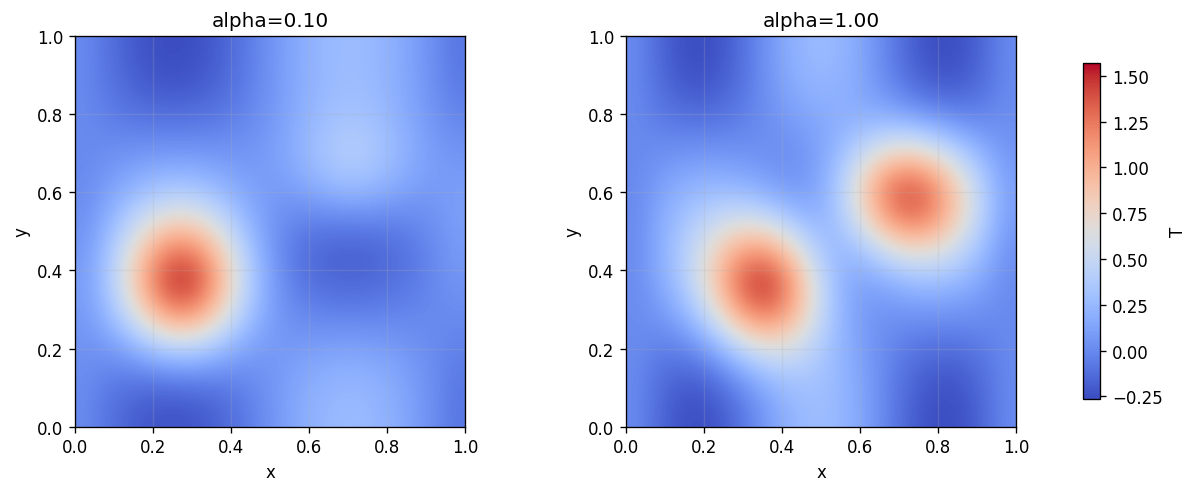

In [2]:

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0), constrained_layout=True)
limits = (float(T.min()), float(T.max()))
spatial_frame(axes[0], T[0], f"alpha={alphas[0]:.2f}", limits)
spatial_frame(axes[1], T[-1], f"alpha={alphas[-1]:.2f}", limits)
fig.colorbar(axes[1].images[0], ax=axes, shrink=0.86, label="T")


## pySensors / RAVEN PostProcessor mapping
<table style="width:100%; table-layout:fixed; border-collapse:collapse;">
<tr>
<th style="width:50%; text-align:left; padding:0.35rem; border-bottom:1px solid #bbb;">pySensors</th>
<th style="width:50%; text-align:left; padding:0.35rem; border-bottom:1px solid #bbb;">RAVEN PostProcessor XML</th>
</tr>
<tr>
<td style="vertical-align:top; padding:0.35rem;">

```python
model = ps.SSPOR(
    basis=ps.basis.SVD(n_basis_modes=4, random_state=42),
    n_sensors=4,
    optimizer=ps.optimizers.TPGR(n_sensors=4),
)
model.fit(T, seed=42)
std = model.std("decreasing", noise=0.2)
one = model.one_pt_energy_landscape(prior="decreasing", noise=0.2)
two = model.two_pt_energy_landscape([selected[0]], prior="decreasing", noise=0.2)
```

</td>
<td style="vertical-align:top; padding:0.35rem;">

```xml
<PostProcessor name="mySPSL" subType="SparseSensing">
  <Goal subType="reconstruction">
    <features>x, y, T</features>
    <target>T</target>
    <basis>SVD</basis>
    <nModes>4</nModes>
    <nSensors>4</nSensors>
    <optimizer>TPGR</optimizer>
    <uncertaintyMetrics>std</uncertaintyMetrics>
    <energyLandscapeMetrics>one_pt,two_pt</energyLandscapeMetrics>
    <energyLandscapeSensors>...</energyLandscapeSensors>
    <uncertaintyNoise>0.2</uncertaintyNoise>
    <seed>42</seed>
  </Goal>
</PostProcessor>
```

</td>
</tr>
</table>

## pySensors TPGR reference

In [3]:

n_modes = 4
n_sensors = 4
uq_noise = 0.2
model = ps.SSPOR(
    basis=ps.basis.SVD(n_basis_modes=n_modes, random_state=seed),
    n_sensors=n_sensors,
    optimizer=ps.optimizers.TPGR(n_sensors=n_sensors),
)
model.fit(T, seed=seed)
selected = model.get_selected_sensors()
std = np.asarray(model.std("decreasing", noise=uq_noise), dtype=float)
one_pt = np.asarray(model.one_pt_energy_landscape(prior="decreasing", noise=uq_noise), dtype=float)
two_pt_reference_sensor = int(selected[0])
two_pt = np.asarray(model.two_pt_energy_landscape([two_pt_reference_sensor], prior="decreasing", noise=uq_noise), dtype=float)

sensor_table = pd.DataFrame({"order": np.arange(1, len(selected) + 1), "sensor_id": selected, "x": X[selected], "y": Y[selected], "T_first_alpha": T[0, selected]})
print(f"two-point landscape conditioned on sensor id: {two_pt_reference_sensor}")
sensor_table


two-point landscape conditioned on sensor id: 77


/Users/abdomg/miniconda3/envs/raven_spsl_043/lib/python3.11/site-packages/pysensors/optimizers/_tpgr.py:76: UserWarning: noise is None. noise will be set to the average of the computed prior.
  warnings.warn(


,order,sensor_id,x,y,T_first_alpha
0,1,77,0.294118,0.363636,1.475061
1,2,78,0.352941,0.363636,1.106978
2,3,76,0.235294,0.363636,1.515462
3,4,121,0.764706,0.545455,0.010698


## Run fresh RAVEN TPGR cases

In [4]:

raven_base_dir = repo_root / "tutorials" / "SparseSensing" / "_raven_runs" / "06_tpgr_uncertainty"
raven_base_dir.mkdir(parents=True, exist_ok=True)
write_steady_external_model(raven_base_dir)

goal_selection = f"""
<features>x, y, T</features><target>T</target><basis>SVD</basis><nModes>{n_modes}</nModes><nSensors>{n_sensors}</nSensors><optimizer>TPGR</optimizer><seed>{seed}</seed>
"""
selection_input = write_steady_xml(raven_base_dir, "tpgr_selection", goal_selection, "sensor")
raven_selection = run_raven(raven_base_dir, selection_input)

comparison_table, raven_indices = compare_sensor_tables("TPGR", selected, raven_selection, T)
print(f"same selected TPGR sensor set: {comparison_table['match'].all() and len(comparison_table) == n_sensors}")
print(f"same selected TPGR sensor order: {np.array_equal(selected, raven_indices)}")
display(style_sensor_comparison(comparison_table, "RAVEN vs pySensors TPGR sensors"))


$ raven_framework tpgr_selection.xml
CONDA
raven_spsl_043       *   /Users/abdomg/miniconda3/envs/raven_spsl_043
Running RAVEN in "opt" mode.

Copyright 2017 Battelle Energy Alliance, LLC

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
  

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

      .---.        .------######       #####     ###   ###  ########  ###    ###
     /     \  __  /    --###  ###    ###  ###   ###   ###  ###       #####  ###
    / /     \(  )/    --###  ###    ###   ##

case,match,order_match,sensor_id,pySensors order,RAVEN order,pySensors value,RAVEN value,pySensors x,RAVEN x,pySensors y,RAVEN y,nearest_grid_distance
TPGR,yes,yes,77,1,1,1.475061,1.475061,0.294118,0.294118,0.363636,0.363636,7.85e-17
TPGR,yes,yes,78,2,2,1.106978,1.106978,0.352941,0.352941,0.363636,0.363636,5.55e-17
TPGR,yes,yes,76,3,3,1.515462,1.515462,0.235294,0.235294,0.363636,0.363636,6.21e-17
TPGR,yes,yes,121,4,4,0.010698,0.010698,0.764706,0.764706,0.545455,0.545455,0.00e+00


## Reconstruction Diagnostics
The selected TPGR sensors are used to reconstruct the full 2D field. The static view shows one alpha snapshot; the error is normalized by the global field magnitude.


alpha,relative_l2_error
0.100,9.452662e-04
0.280,2.415539e-03
0.460,1.364376e-03
0.640,1.429587e-03
0.820,1.957540e-03
1.000,6.352570e-04


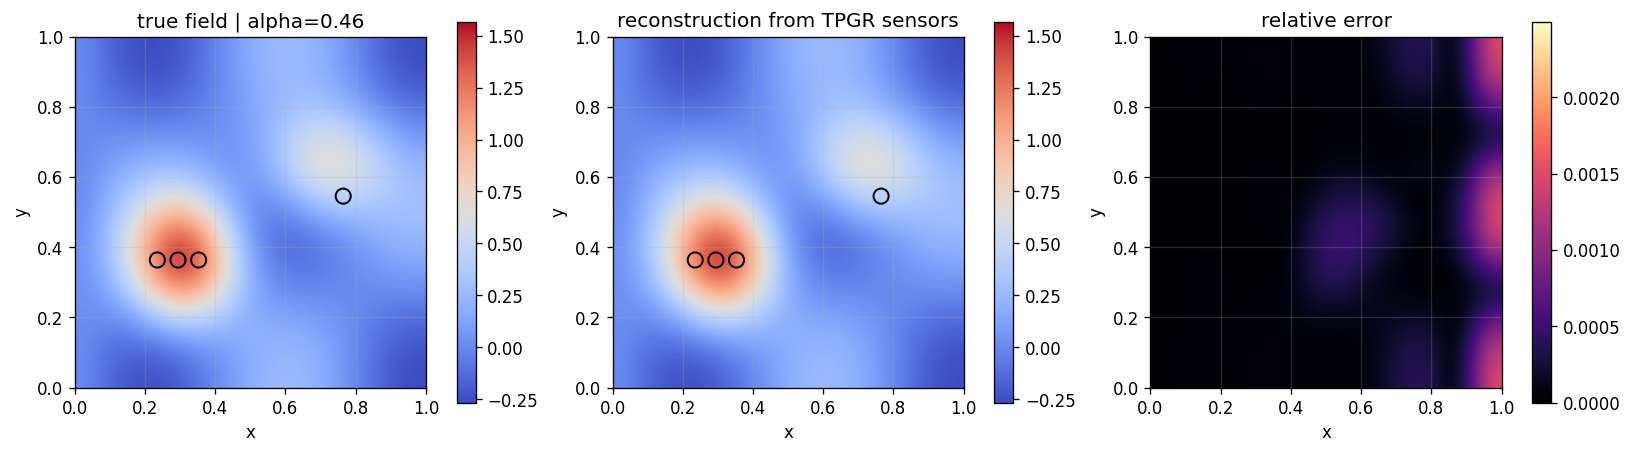

In [5]:

tpgr_reconstruction = model.predict(T[:, selected], method="unregularized")
tpgr_relative_error = np.abs(tpgr_reconstruction - T) / max(float(np.max(np.abs(T))), 1e-12)
tpgr_relative_l2 = np.linalg.norm(tpgr_reconstruction - T, axis=1) / np.maximum(np.linalg.norm(T, axis=1), 1e-12)

reconstruction_table = pd.DataFrame({"alpha": alphas, "relative_l2_error": tpgr_relative_l2})
display(reconstruction_table.style.format({"alpha": "{:.3f}", "relative_l2_error": "{:.6e}"}).hide(axis="index"))

sample_index = min(2, len(alphas) - 1)
field_limits = (float(np.min(T)), float(np.max(T)))
error_limits = (0.0, max(float(np.max(tpgr_relative_error)), 1e-12))
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0), constrained_layout=True)
panels = [
    (T[sample_index], f"true field | alpha={alphas[sample_index]:.2f}", "coolwarm", field_limits),
    (tpgr_reconstruction[sample_index], "reconstruction from TPGR sensors", "coolwarm", field_limits),
    (tpgr_relative_error[sample_index], "relative error", "magma", error_limits),
]
for ax, (values, title, cmap, limits) in zip(axes, panels):
    im = spatial_frame(ax, values, title, limits=limits, cmap=cmap, sensors=selected)
    fig.colorbar(im, ax=ax, shrink=0.82)


In [6]:

goal_landscape = f"""
<features>x, y, T</features><target>T</target><basis>SVD</basis><nModes>{n_modes}</nModes><nSensors>{n_sensors}</nSensors><optimizer>TPGR</optimizer><uncertaintyMetrics>std</uncertaintyMetrics><energyLandscapeMetrics>one_pt,two_pt</energyLandscapeMetrics><energyLandscapeSensors>{two_pt_reference_sensor}</energyLandscapeSensors><uncertaintyNoise>{uq_noise}</uncertaintyNoise><seed>{seed}</seed>
"""
landscape_input = write_steady_xml(raven_base_dir, "tpgr_landscapes", goal_landscape, "candidate_tpgr")
raven_landscapes = run_raven(raven_base_dir, landscape_input).sort_values("candidateSensor").reset_index(drop=True)

metric_compare = pd.DataFrame({
    "sensor_id": point_id,
    "py_std": std,
    "RAVEN_std": raven_landscapes["std"].to_numpy(),
    "py_one_pt": one_pt,
    "RAVEN_one_pt": raven_landscapes["onePtEnergyLandscape"].to_numpy(),
    "py_two_pt": two_pt,
    "RAVEN_two_pt": raven_landscapes["twoPtEnergyLandscape"].to_numpy(),
})
for name in ["std", "one_pt", "two_pt"]:
    metric_compare[f"{name}_match"] = np.isclose(metric_compare[f"py_{name}"], metric_compare[f"RAVEN_{name}"], rtol=1e-10, atol=1e-10, equal_nan=True)
print(metric_compare[["std_match", "one_pt_match", "two_pt_match"]].all())
metric_compare.head(10)


$ raven_framework tpgr_landscapes.xml
CONDA
raven_spsl_043       *   /Users/abdomg/miniconda3/envs/raven_spsl_043
Running RAVEN in "opt" mode.

Copyright 2017 Battelle Energy Alliance, LLC

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
  

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

      .---.        .------######       #####     ###   ###  ########  ###    ###
     /     \  __  /    --###  ###    ###  ###   ###   ###  ###       #####  ###
    / /     \(  )/    --###  ###    ###   #

,sensor_id,py_std,RAVEN_std,py_one_pt,RAVEN_one_pt,py_two_pt,RAVEN_two_pt,std_match,one_pt_match,two_pt_match
0,0,0.000250,0.000250,-0.000040,-0.000040,0.000014,0.000014,True,True,True
1,1,0.010121,0.010121,-0.299633,-0.299633,0.124542,0.124542,True,True,True
2,2,0.017065,0.017065,-0.724723,-0.724723,0.249755,0.249755,True,True,True
3,3,0.019283,0.019283,-0.902286,-0.902286,0.290847,0.290847,True,True,True
4,4,0.019194,0.019194,-0.796047,-0.796047,0.268891,0.268891,True,True,True
5,5,0.023279,0.023279,-0.484920,-0.484920,0.169516,0.169516,True,True,True
6,6,0.031254,0.031254,-0.223593,-0.223593,0.023834,0.023834,True,True,True
7,7,0.036196,0.036196,-0.314803,-0.314803,0.030608,0.030608,True,True,True
8,8,0.033789,0.033789,-0.600936,-0.600936,0.155269,0.155269,True,True,True
9,9,0.024582,0.024582,-0.804610,-0.804610,0.248070,0.248070,True,True,True


## Uncertainty and energy landscape maps

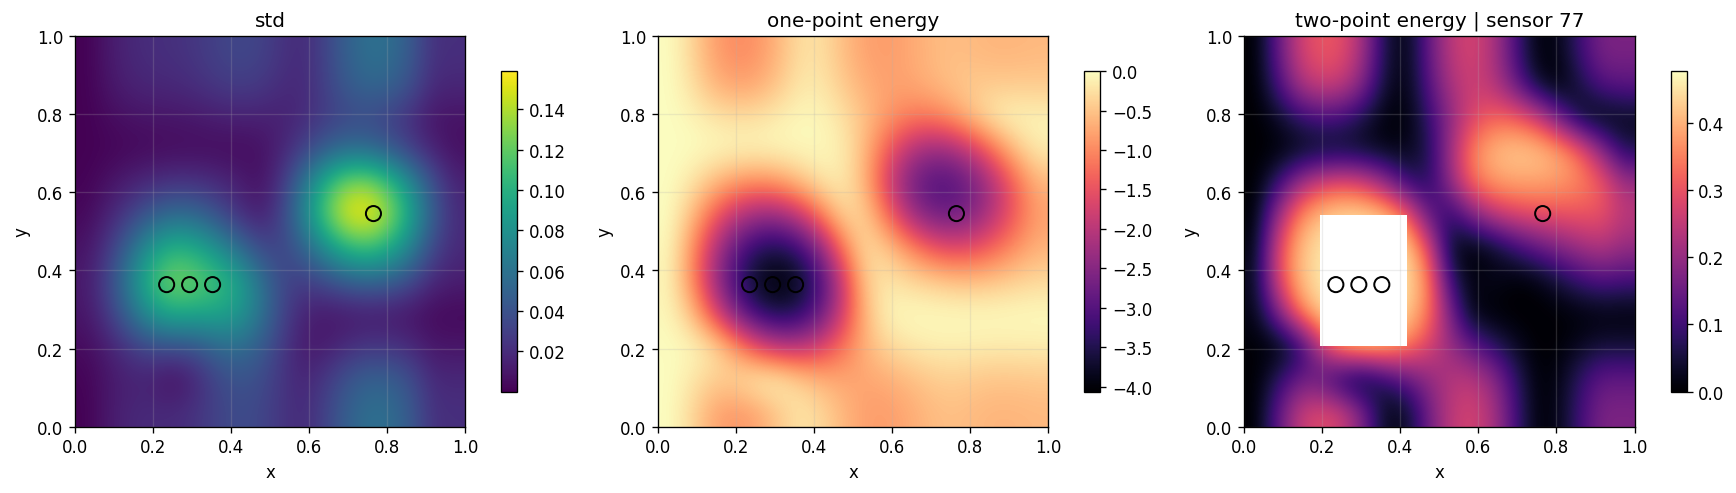

In [7]:

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.0), constrained_layout=True)
plots = [
    (std, "std", "viridis"),
    (one_pt, "one-point energy", "magma"),
    (two_pt, f"two-point energy | sensor {two_pt_reference_sensor}", "magma"),
]
for ax, (values, title, cmap) in zip(axes, plots):
    im = spatial_frame(ax, values, title, cmap=cmap, sensors=selected)
    fig.colorbar(im, ax=ax, shrink=0.82)
